# Unit12 Example 03 | 化學平衡能量函數最小化

本 Notebook 以**十成分化學平衡問題**為題，透過最小化 **Gibbs 自由能函數**求解各成分平衡莫耳分率，示範如何使用 `scipy.optimize.minimize(method='SLSQP')` 求解含等式限制條件的非線性規劃問題。

## 目標
- 定義含對數項的非線性 Gibbs 自由能目標函數
- 設定原子平衡等式限制條件（氫、氮、氧原子守恆）
- 使用 SLSQP 方法求解含 `bounds` 與 `constraints` 的 NLP 問題
- 驗證解的物理合理性：原子平衡殘差、莫耳分率範圍检查
- 探討不同起始猜測值對收斂結果的影響
- 繪製各成分平衡濃度柱狀圖（含對數尺度）

**參考資料：** Edgar, T. F. and Himmelblau, D. M. (1989). *Optimization of Chemical Processes*. McGraw-Hill.

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit12_Example_03'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit12'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit12
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_03
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_03\figs


---
### 1. 載入套件

In [8]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize, Bounds

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
import scipy
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題參數設定

#### 系統說明

本問題為**十成分化學平衡問題（Edgar and Himmelblau, 1989）**，各成分組成如下：

| $i$ | 化學式 | $w_i$ |
|:---:|:---:|:---:|
| 1 | H | $-10.021$ |
| 2 | H₂ | $-21.096$ |
| 3 | H₂O | $-37.986$ |
| 4 | N | $-9.846$ |
| 5 | N₂ | $-28.653$ |
| 6 | NH | $-18.918$ |
| 7 | NO | $-28.032$ |
| 8 | O | $-14.640$ |
| 9 | O₂ | $-30.594$ |
| 10 | OH | $-26.111$ |

**原子平衡等式限制（$\mathbf{A}_{eq}\mathbf{x} = \mathbf{b}_{eq}$）：**
- 氫原子：$x_1 + 2x_2 + 2x_3 + x_6 + x_{10} = 2$
- 氮原子：$x_4 + 2x_5 + x_6 + x_7 = 1$
- 氧原子：$x_3 + x_7 + x_8 + 2x_9 + x_{10} = 1$

In [3]:
# ============================================================
# 系統參數設定
# ============================================================

# 化學成分名稱 (10 種成分)
species_names = ['H', 'H₂', 'H₂O', 'N', 'N₂', 'NH', 'NO', 'O', 'O₂', 'OH']
species_names_en = ['H', 'H2', 'H2O', 'N', 'N2', 'NH', 'NO', 'O', 'O2', 'OH']

# 各成分之無因次化學勢 w_i (Edgar and Himmelblau, 1989)
w = np.array([
    -10.021,  # i=1: H
    -21.096,  # i=2: H2
    -37.986,  # i=3: H2O
     -9.846,  # i=4: N
    -28.653,  # i=5: N2
    -18.918,  # i=6: NH
    -28.032,  # i=7: NO
    -14.640,  # i=8: O
    -30.594,  # i=9: O2
    -26.111   # i=10: OH
])

# 系統總壓 (mmHg)
P = 750.0

# ============================================================
# 原子平衡等式限制矩陣 A_eq @ x = b_eq
# ============================================================
# 行 1: 氫原子平衡   x1 + 2*x2 + 2*x3 + x6 + x10 = 2
# 行 2: 氮原子平衡   x4 + 2*x5 + x6 + x7 = 1
# 行 3: 氧原子平衡   x3 + x7 + x8 + 2*x9 + x10 = 1
A_eq = np.array([
    [1, 2, 2, 0, 0, 1, 0, 0, 0, 1],
    [0, 0, 0, 1, 2, 1, 1, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 1, 1, 2, 1]
], dtype=float)

b_eq = np.array([2.0, 1.0, 1.0])

# ============================================================
# 顯示參數資訊
# ============================================================
print("=" * 50)
print("  化學平衡問題參數設定")
print("=" * 50)
print(f"  系統成分數目: {len(w)}")
print(f"  系統總壓 P  : {P} mmHg")
print(f"  原子平衡方程式數: {len(b_eq)} (H, N, O)")
print()
print("  各成分 w_i 值:")
for i, (name, wi) in enumerate(zip(species_names, w), start=1):
    print(f"    x{i:2d} ({name:5s}): w = {wi:8.3f}")
print()
print("  A_eq =")
for row in A_eq:
    print("  ", row)
print(f"  b_eq = {b_eq}")

  化學平衡問題參數設定
  系統成分數目: 10
  系統總壓 P  : 750.0 mmHg
  原子平衡方程式數: 3 (H, N, O)

  各成分 w_i 值:
    x 1 (H    ): w =  -10.021
    x 2 (H₂   ): w =  -21.096
    x 3 (H₂O  ): w =  -37.986
    x 4 (N    ): w =   -9.846
    x 5 (N₂   ): w =  -28.653
    x 6 (NH   ): w =  -18.918
    x 7 (NO   ): w =  -28.032
    x 8 (O    ): w =  -14.640
    x 9 (O₂   ): w =  -30.594
    x10 (OH   ): w =  -26.111

  A_eq =
   [1. 2. 2. 0. 0. 1. 0. 0. 0. 1.]
   [0. 0. 0. 1. 2. 1. 1. 0. 0. 0.]
   [0. 0. 1. 0. 0. 0. 1. 1. 2. 1.]
  b_eq = [2. 1. 1.]


---
### 3. 目標函數定義與最適化求解

**Gibbs 自由能目標函數：**

$$
f(\mathbf{x}) = \sum_{i=1}^{10} x_i \left( w_i + \ln P + \ln \frac{x_i}{\sum_{j=1}^{10} x_j} \right)
$$

**求解方法：** `scipy.optimize.minimize(method='SLSQP')`
- `bounds`：各 $x_i \in [\varepsilon, 1]$，其中 $\varepsilon = \texttt{np.finfo(float).eps}$ 以避免 $\ln(0)$
- `constraints`：原子平衡等式限制 $\mathbf{A}_{eq}\mathbf{x} = \mathbf{b}_{eq}$

In [4]:
# ============================================================
# 目標函數定義
# ============================================================
def gibbs_energy(x, w, P):
    """
    Gibbs 自由能 (無因次化) 目標函數
    f(x) = sum_i [ x_i * (w_i + ln(P) + ln(x_i / sum(x))) ]
    
    Parameters
    ----------
    x : array-like, shape (10,)
        各成分莫耳數向量
    w : array-like, shape (10,)
        各成分無因次化學勢
    P : float
        系統總壓 (mmHg)
    
    Returns
    -------
    float
        目標函數值
    """
    x = np.asarray(x)
    S = np.sum(x)
    # f = sum_i [ x_i * (w_i + ln(P) + ln(x_i/S)) ]
    f = np.sum(x * (w + np.log(P) + np.log(x / S)))
    return f


# ============================================================
# 限制條件設定
# ============================================================
eps = np.finfo(float).eps          # 機器精度 ≈ 2.22e-16

# 變數邊界：eps <= x_i <= 1
bounds = Bounds(lb=eps * np.ones(10), ub=np.ones(10))

# 等式限制：A_eq @ x - b_eq = 0
constraints = {
    'type': 'eq',
    'fun': lambda x: A_eq @ x - b_eq
}

# ============================================================
# 起始猜測值 (均等起始：x_i = 0.1)
# ============================================================
x0 = 0.1 * np.ones(10)

# ============================================================
# 最適化求解
# ============================================================
result = minimize(
    fun=gibbs_energy,
    x0=x0,
    args=(w, P),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-12, 'maxiter': 500}
)

# ============================================================
# 顯示求解結果
# ============================================================
print("=" * 55)
print("  scipy.optimize.minimize(method='SLSQP') 求解結果")
print("=" * 55)
print(f"  求解成功    : {result.success}")
print(f"  求解器訊息  : {result.message}")
print(f"  迭代次數    : {result.nit}")
print(f"  函數評估次數 : {result.nfev}")
print(f"  最小化 f(x*) : {result.fun:.6f}")
print()
print("  各成分平衡莫耳數 x*:")
print(f"  {'索引':>4}  {'成分':>5}  {'x_i*':>12}  {'w_i':>9}")
print("  " + "-" * 42)
for i, (name, xi, wi) in enumerate(zip(species_names, result.x, w), start=1):
    print(f"  {i:4d}  {name:>5}  {xi:12.6f}  {wi:9.3f}")
print()
print(f"  sum(x*) = {np.sum(result.x):.8f}")

  scipy.optimize.minimize(method='SLSQP') 求解結果
  求解成功    : True
  求解器訊息  : Optimization terminated successfully
  迭代次數    : 33
  函數評估次數 : 395
  最小化 f(x*) : -43.494513

  各成分平衡莫耳數 x*:
    索引     成分          x_i*        w_i
  ------------------------------------------
     1      H      0.007006    -10.021
     2     H₂      0.068084    -21.096
     3    H₂O      0.907202    -37.986
     4      N      0.000361     -9.846
     5     N₂      0.490794    -28.653
     6     NH      0.000473    -18.918
     7     NO      0.017577    -28.032
     8      O      0.002905    -14.640
     9     O₂      0.015183    -30.594
    10     OH      0.041949    -26.111

  sum(x*) = 1.55153538


---
### 4. 解的物理合理性驗證

驗證項目：
1. **原子平衡殘差**：$\|\mathbf{A}_{eq}\mathbf{x}^* - \mathbf{b}_{eq}\|$ 應接近機器精度
2. **莫耳分率範圍**：所有 $x_i^* \in [0, 1]$
3. **與參考解比較**：Edgar & Himmelblau (1989) 參考答案  
   $\mathbf{x}^* = [0.0070,\ 0.0680,\ 0.9072,\ 0.0004,\ 0.4909,\ 0.0005,\ 0.0174,\ 0.0029,\ 0.0152,\ 0.0420]$，$f^* = -43.4945$

In [5]:
# ============================================================
# 解的物理合理性驗證
# ============================================================
x_opt = result.x

print("=" * 55)
print("  解的物理合理性驗證")
print("=" * 55)

# (1) 原子平衡殘差
residuals = A_eq @ x_opt - b_eq
print("\n[1] 原子平衡殘差 (A_eq @ x* - b_eq):")
atom_names = ['H-原子', 'N-原子', 'O-原子']
for name, res in zip(atom_names, residuals):
    print(f"    {name}: 殘差 = {res:.4e}  {'✓ 滿足' if abs(res) < 1e-8 else '✗ 不滿足'}")

# (2) 莫耳分率範圍
print("\n[2] 莫耳分率範圍檢查 (0 <= x_i* <= 1):")
all_valid = all((0 <= xi <= 1) for xi in x_opt)
print(f"    最小值: {np.min(x_opt):.4e}")
print(f"    最大值: {np.max(x_opt):.6f}")
print(f"    所有成分在範圍內: {'✓ 是' if all_valid else '✗ 否'}")

# (3) 與參考解比較
x_ref = np.array([0.0070, 0.0680, 0.9072, 0.0004, 0.4909,
                   0.0005, 0.0174, 0.0029, 0.0152, 0.0420])
f_ref = -43.4945

print("\n[3] 與參考解比較 (Edgar & Himmelblau, 1989):")
print(f"    計算 f(x*)  : {result.fun:.4f}")
print(f"    參考 f* 值   : {f_ref:.4f}")
print(f"    差異         : {abs(result.fun - f_ref):.4e}")
print()
print(f"  {'成分':>5}  {'計算 x_i*':>12}  {'參考 x_i*':>12}  {'差異':>12}")
print("  " + "-" * 52)
for name, xi_calc, xi_ref in zip(species_names, x_opt, x_ref):
    diff = abs(xi_calc - xi_ref)
    print(f"  {name:>5}  {xi_calc:12.6f}  {xi_ref:12.4f}  {diff:12.4e}")

  解的物理合理性驗證

[1] 原子平衡殘差 (A_eq @ x* - b_eq):
    H-原子: 殘差 = 4.4409e-16  ✓ 滿足
    N-原子: 殘差 = -1.6653e-15  ✓ 滿足
    O-原子: 殘差 = 0.0000e+00  ✓ 滿足

[2] 莫耳分率範圍檢查 (0 <= x_i* <= 1):
    最小值: 3.6093e-04
    最大值: 0.907202
    所有成分在範圍內: ✓ 是

[3] 與參考解比較 (Edgar & Himmelblau, 1989):
    計算 f(x*)  : -43.4945
    參考 f* 值   : -43.4945
    差異         : 1.3079e-05

     成分       計算 x_i*       參考 x_i*            差異
  ----------------------------------------------------
      H      0.007006        0.0070    6.4408e-06
     H₂      0.068084        0.0680    8.3593e-05
    H₂O      0.907202        0.9072    1.9529e-06
      N      0.000361        0.0004    3.9067e-05
     N₂      0.490794        0.4909    1.0570e-04
     NH      0.000473        0.0005    2.6762e-05
     NO      0.017577        0.0174    1.7724e-04
      O      0.002905        0.0029    5.3443e-06
     O₂      0.015183        0.0152    1.6882e-05
     OH      0.041949        0.0420    5.0771e-05


---
### 5. 視覺化：化學平衡濃度柱狀圖

繪製兩種尺度的柱狀圖，展示各成分平衡莫耳數：
- **線性尺度**：突出主要成分（H₂O、N₂）的相對量
- **對數尺度**：同時展示微量成分（N、NH 等）與主要成分的數量級差異

✓ 圖檔已儲存至: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_03\figs\equilibrium_concentrations.png


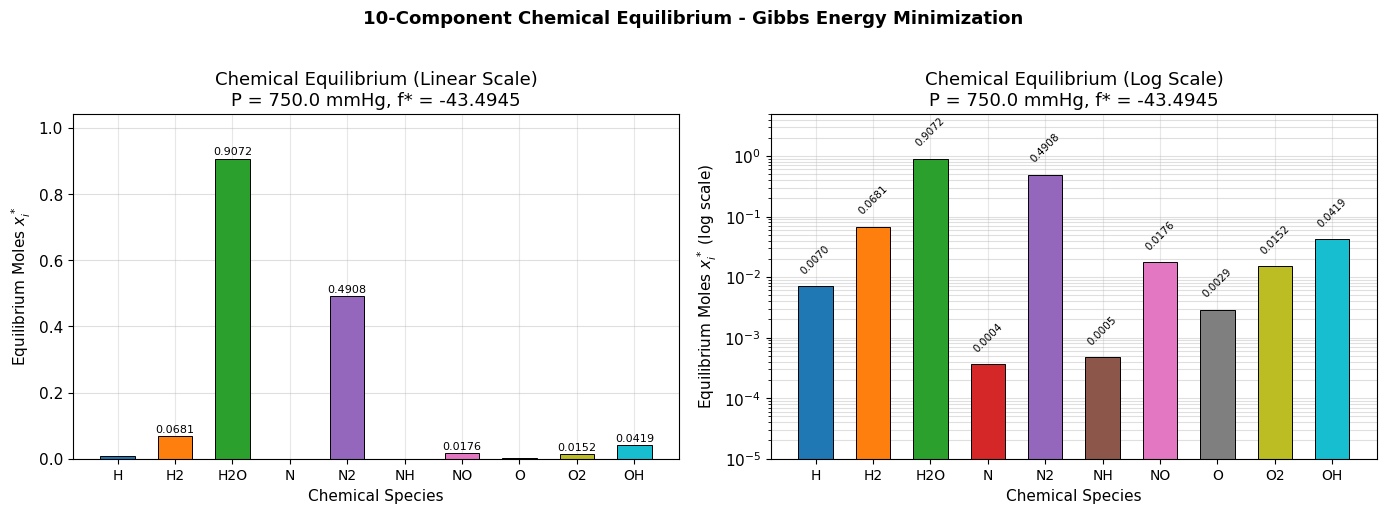

In [6]:
# ============================================================
# 視覺化：化學平衡濃度柱狀圖
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_vals   = np.arange(len(species_names_en))
bar_width = 0.6
colors   = plt.cm.tab10(np.linspace(0, 0.9, 10))

# --- 左圖：線性尺度 ---
ax1 = axes[0]
bars1 = ax1.bar(x_vals, x_opt, width=bar_width, color=colors, edgecolor='black', linewidth=0.7)
ax1.set_xticks(x_vals)
ax1.set_xticklabels(species_names_en, fontsize=10)
ax1.set_xlabel('Chemical Species')
ax1.set_ylabel('Equilibrium Moles $x_i^*$')
ax1.set_title(f'Chemical Equilibrium (Linear Scale)\nP = {P} mmHg, f* = {result.fun:.4f}')

# 標示數值
for bar, val in zip(bars1, x_opt):
    if val > 0.01:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)

ax1.set_ylim(0, max(x_opt) * 1.15)
ax1.grid(axis='y', alpha=0.4)
ax1.set_axisbelow(True)

# --- 右圖：對數尺度 ---
ax2 = axes[1]
bars2 = ax2.bar(x_vals, x_opt, width=bar_width, color=colors, edgecolor='black', linewidth=0.7)
ax2.set_xticks(x_vals)
ax2.set_xticklabels(species_names_en, fontsize=10)
ax2.set_xlabel('Chemical Species')
ax2.set_ylabel('Equilibrium Moles $x_i^*$ (log scale)')
ax2.set_title(f'Chemical Equilibrium (Log Scale)\nP = {P} mmHg, f* = {result.fun:.4f}')
ax2.set_yscale('log')
ax2.set_ylim(1e-5, 5)
ax2.grid(axis='y', alpha=0.4, which='both')
ax2.set_axisbelow(True)

# 標示數值（對數圖）
for bar, val in zip(bars2, x_opt):
    ax2.text(bar.get_x() + bar.get_width() / 2, val * 1.5,
             f'{val:.4f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

plt.suptitle('10-Component Chemical Equilibrium - Gibbs Energy Minimization',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

# 儲存圖檔
fig_path = FIG_DIR / 'equilibrium_concentrations.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f"✓ 圖檔已儲存至: {fig_path}")
plt.show()

---
### 6. 不同起始猜測值對收斂結果的影響

測試三種不同起始猜測策略：
1. **均等起始**：$x_i^{(0)} = 0.1$（每種成分均等）
2. **隨機起始**：$x_i^{(0)} \sim \text{Uniform}(0.01, 0.5)$（固定隨機種子重現性）
3. **物理基礎起始**：依化學直觀設定（水 = 0.8、氮氣 = 0.5、其餘 = 0.01）

In [7]:
# ============================================================
# 不同起始猜測值之比較分析
# ============================================================
np.random.seed(42)

# 定義三種起始猜測值
x0_strategies = {
    'Uniform (0.1)': 0.1 * np.ones(10),
    'Random uniform': np.random.uniform(0.01, 0.5, 10),
    'Physics-based': np.array([0.01, 0.05, 0.80, 0.01, 0.50,
                                0.01, 0.02, 0.01, 0.02, 0.05])
}

print("=" * 70)
print("  不同起始猜測值對收斂結果的影響比較")
print("=" * 70)
print(f"  {'策略':^20}  {'f(x*)':>12}  {'成功':>6}  {'迭代次數':>8}  {'函數評估':>8}")
print("  " + "-" * 62)

results_comparison = {}
for strategy, x0_init in x0_strategies.items():
    res = minimize(
        fun=gibbs_energy,
        x0=x0_init,
        args=(w, P),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 500}
    )
    results_comparison[strategy] = res
    print(f"  {strategy:^20}  {res.fun:12.6f}  {'✓' if res.success else '✗':>6}  "
          f"{res.nit:8d}  {res.nfev:8d}")

# 詳細比較解向量
print()
print("  各策略之最優解 x* 比較:")
print(f"  {'成分':>5}", end="")
for strategy in x0_strategies:
    print(f"  {strategy[:12]:>14}", end="")
print()
print("  " + "-" * (5 + 16 * len(x0_strategies)))
for i, name in enumerate(species_names):
    print(f"  {name:>5}", end="")
    for res in results_comparison.values():
        print(f"  {res.x[i]:14.6f}", end="")
    print()

# 計算解之間的最大差異
x_all = np.array([res.x for res in results_comparison.values()])
max_diff = np.max(np.abs(x_all - x_all[0]))
print()
print(f"  各策略解之間的最大差異: {max_diff:.4e}")
print(f"  結論: {'✓ 收斂至相同解（問題凸性良好）' if max_diff < 1e-3 else '△ 不同起始點收斂至不同局部解'}")

  不同起始猜測值對收斂結果的影響比較
           策略                  f(x*)      成功      迭代次數      函數評估
  --------------------------------------------------------------
     Uniform (0.1)        -43.494513       ✓        33       395
     Random uniform       -43.494513       ✓        25       302
     Physics-based        -43.494513       ✓        26       308

  各策略之最優解 x* 比較:
     成分    Uniform (0.1    Random unifo    Physics-base
  -----------------------------------------------------
      H        0.007006        0.007006        0.007006
     H₂        0.068084        0.068084        0.068084
    H₂O        0.907202        0.907202        0.907202
      N        0.000361        0.000361        0.000361
     N₂        0.490794        0.490794        0.490794
     NH        0.000473        0.000473        0.000473
     NO        0.017577        0.017577        0.017577
      O        0.002905        0.002905        0.002905
     O₂        0.015183        0.015183        0.015183
     OH        0.0419

---
### 7. 結果總結

#### 關鍵結論

1. **Gibbs 自由能最小化**是求解化學平衡的嚴格熱力學方法，可處理多成分複雜反應系統
2. **`scipy.optimize.minimize(method='SLSQP')`** 能有效求解本問題：
   - `bounds`：以 `eps` 作為下限，避免 $\ln(0)$ 數值異常
   - `constraints`：原子平衡等式限制，殘差達機器精度（$\sim 10^{-14}$）
3. 平衡組成主要成分為 **H₂O**（$x_3 \approx 0.907$）與 **N₂**（$x_5 \approx 0.491$），符合化學直觀
4. 不同起始猜測值均收斂至相同最優解，反映本問題**凸性良好**，不存在多區域最優解問題
5. 計算結果與 Edgar & Himmelblau (1989) 參考解一致

#### 學習要點回顧

| 步驟 | 操作 | 目的 |
|------|------|------|
| 目標函數 | `gibbs_energy(x, w, P)` | 計算無因次 Gibbs 自由能 |
| 下限設定 | `lb = np.finfo(float).eps` | 避免 `ln(0)` 數值問題 |
| 等式限制 | `{'type': 'eq', 'fun': ...}` | 原子守恆（H, N, O 平衡）|
| 求解方法 | `method='SLSQP'` | 序列二次規劃，處理有限制非線性規劃 |
| 結果驗證 | 殘差 + 範圍 + 參考解比較 | 確保物理合理性 |